In [ ]:
## 9. Що часто питають на тесті

### Linear

- побудувати модель
- записати рівняння
- знайти `R2`
- інтерпретувати коефіцієнт
- зробити residual analysis

### Logistic

- побудувати модель
- знайти `b0`, `b1`
- обчислити ймовірність для конкретного `x`
- побудувати logistic curve
- зробити confusion matrix
- знайти accuracy

## 10. Що не забути

- перед кожним блоком коду зробити Markdown-заголовок
- залишити лише фінальний чистий розв'язок
- якщо є `Sex`, перекодувати в числа
- усі графіки мають мати підписи осей
- не залишати 2 різні варіанти відповіді

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df_HS21 = pd.read_csv('autos.csv', index_col=0)

In [ ]:
df_HS21.head()

,geschwindigkeit,distanz
1,4,2
2,4,10
3,7,4
4,5,12
5,8,16


Text(0, 0.5, 'Geschwindigkeit (km/h)')

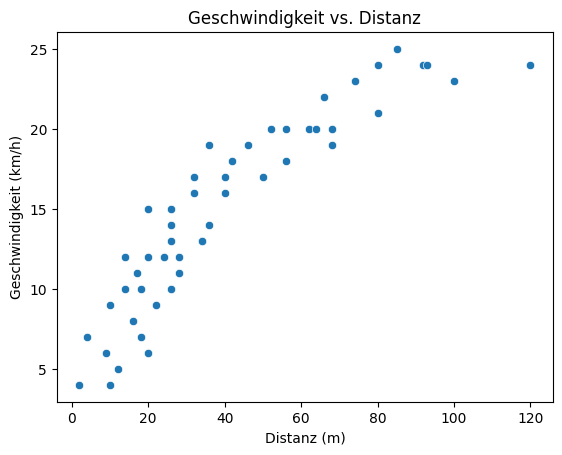

In [ ]:
# plotting geschwindigkeit vs. distanz
sns.scatterplot(x='distanz', y='geschwindigkeit', data=df_HS21)
plt.title('Geschwindigkeit vs. Distanz')
plt.xlabel('Distanz (m)')
plt.ylabel('Geschwindigkeit (km/h)')

In [ ]:
geschwindigkeit_mean = df_HS21['geschwindigkeit'].mean()
geschwindigkeit_mean

np.float64(14.96)

In [ ]:
distanz_mean = df_HS21['distanz'].mean()
distanz_mean

np.float64(40.96)

In [ ]:
df_HS21['geschwindigkeit-mean'] = df_HS21['geschwindigkeit'] - geschwindigkeit_mean
df_HS21['distanz-mean'] = df_HS21['distanz'] - distanz_mean

In [ ]:
df_HS21['multiplication'] = df_HS21['geschwindigkeit-mean'] * df_HS21['distanz-mean']

In [ ]:
df_HS21[ 'scware'] = df_HS21['distanz-mean'] ** 2

In [ ]:
df_HS21.head()

,geschwindigkeit,distanz,geschwindigkeit-mean,distanz-mean,multiplication,scware
1,4,2,-10.96,-38.96,427.0016,1517.8816
2,4,10,-10.96,-30.96,339.3216,958.5216
3,7,4,-7.96,-36.96,294.2016,1366.0416
4,5,12,-9.96,-28.96,288.4416,838.6816
5,8,16,-6.96,-24.96,173.7216,623.0016


In [ ]:
B = df_HS21['multiplication'].sum() / df_HS21['scware'].sum()

In [22]:
a = geschwindigkeit_mean - B * distanz_mean

Text(0, 0.5, 'Geschwindigkeit (km/h)')

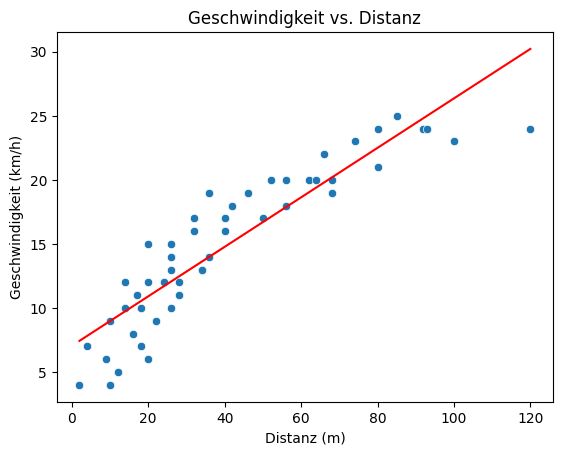

In [ ]:
sns.lineplot(x=df_HS21['distanz'], y=a + B * df_HS21['distanz'], color='red')
sns.scatterplot(x='distanz', y='geschwindigkeit', data=df_HS21)
plt.title('Geschwindigkeit vs. Distanz')
plt.xlabel('Distanz (m)')
plt.ylabel('Geschwindigkeit (km/h)')

In [25]:
formula = f"geschwindigkeit = {a:.3f} + {B:.3f} * distanz"
print(formula)

geschwindigkeit = 7.052 + 0.193 * distanz


geschwindigkeit = 7.052 + 0.193 * distanz


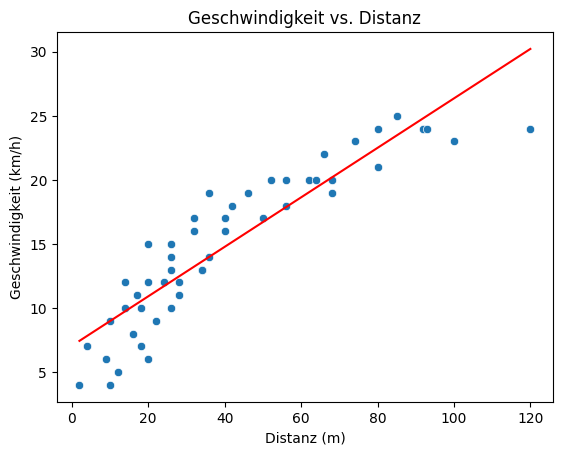

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

X = df_HS21[['distanz']]                  # ознака
y = df_HS21['geschwindigkeit']            # ціль

model = LinearRegression()
model.fit(X, y)

B = model.coef_[0]                   # нахил
a = model.intercept_                 # перетин з віссю y

print(f"geschwindigkeit = {a:.3f} + {B:.3f} * distanz")

# графік
sns.scatterplot(x='distanz', y='geschwindigkeit', data=df_HS21)
x_line = np.linspace(df_HS21['distanz'].min(), df_HS21['distanz'].max(), 100)
y_line = a + B * x_line
plt.plot(x_line, y_line, color='red')
plt.title('Geschwindigkeit vs. Distanz')
plt.xlabel('Distanz (m)')
plt.ylabel('Geschwindigkeit (km/h)')
plt.show()

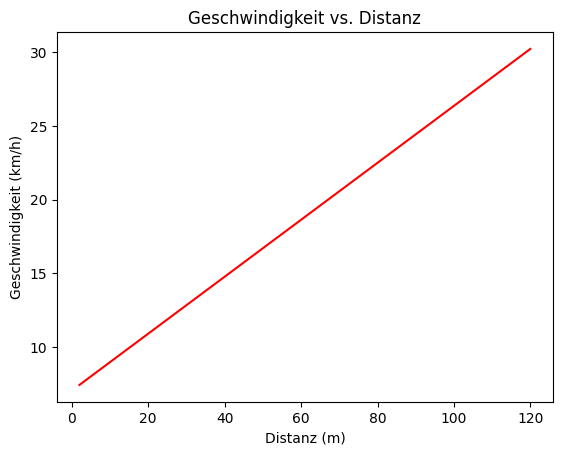

In [ ]:

x_line = np.linspace(df_HS21['distanz'].min(), df_HS21['distanz'].max(), 100)
y_line = a + B * x_line
plt.plot(x_line, y_line, color='red')
plt.title('Geschwindigkeit vs. Distanz')
plt.xlabel('Distanz (m)')
plt.ylabel('Geschwindigkeit (km/h)')
plt.show()

# Residuen berechnen
y_pred = model.predict(X)
residuen = y - y_pred

# 1) Residuenplot: Residuen gegen vorhergesagte Werte
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuen, alpha=0.8)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuenplot')
plt.xlabel('Vorhergesagte Geschwindigkeit (km/h)')
plt.ylabel('Residuen (Ist - Prognose)')
plt.show()

# 2) Verteilung der Residuen
plt.figure(figsize=(8, 5))
sns.histplot(residuen, kde=True)
plt.title('Verteilung der Residuen')
plt.xlabel('Residuen')
plt.ylabel('Haeufigkeit')
plt.show()

# Optional: Kennzahlen
print('Mittelwert der Residuen:', residuen.mean())
print('Standardabweichung der Residuen:', residuen.std())

In [36]:
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

alpha = 0.05

# Fuer Breusch-Pagan brauchen wir eine Design-Matrix mit Konstante
X_bp = sm.add_constant(X)

# 1) Shapiro-Wilk-Test (Normalitaet)
shapiro_stat, shapiro_p = shapiro(residuen)

# 2) Breusch-Pagan-Test (Homoskedastizitaet)
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuen, X_bp)

# 3) Durbin-Watson (Autokorrelation)
dw = durbin_watson(residuen)

print('Signifikanzniveau alpha =', alpha)
print('---')
print(f'Shapiro-Wilk: Statistik = {shapiro_stat:.4f}, p-Wert = {shapiro_p:.4f}')
print('Entscheidung:', 'H0 nicht verwerfen (Normalitaet plausibel)' if shapiro_p >= alpha else 'H0 verwerfen (keine Normalitaet)')
print('---')
print(f'Breusch-Pagan (LM): Statistik = {bp_lm:.4f}, p-Wert = {bp_lm_p:.4f}')
print('Entscheidung:', 'H0 nicht verwerfen (Homoskedastizitaet plausibel)' if bp_lm_p >= alpha else 'H0 verwerfen (Hinweis auf Heteroskedastizitaet)')
print('---')
print(f'Durbin-Watson = {dw:.4f}')
if 1.5 <= dw <= 2.5:
    print('Interpretation: keine starke Autokorrelation erkennbar.')
elif dw < 1.5:
    print('Interpretation: Hinweis auf positive Autokorrelation.')
else:
    print('Interpretation: Hinweis auf negative Autokorrelation.')

Signifikanzniveau alpha = 0.05
---
Shapiro-Wilk: Statistik = 0.9810, p-Wert = 0.5940
Entscheidung: H0 nicht verwerfen (Normalitaet plausibel)
---
Breusch-Pagan (LM): Statistik = 0.0542, p-Wert = 0.8159
Entscheidung: H0 nicht verwerfen (Homoskedastizitaet plausibel)
---
Durbin-Watson = 1.6276
Interpretation: keine starke Autokorrelation erkennbar.
